# Phishing Website Detection Using Machine Learning

## Data Science in Cybersecurity – Final Project

### Project Objective
** Student - Tasneem Mrahel

The objective of this project is to analyze a phishing website dataset and develop machine learning models capable of distinguishing phishing websites from legitimate ones.

The project is based on the following resources:

- **Paper:** Datasets for Phishing Websites Detection
- **GitHub Repository:** https://github.com/GregaVrbancic/Phishing-Dataset

The notebook includes:

- Data Loading
- Exploratory Data Analysis (EDA)
- Feature Engineering
- Model Training
- Model Evaluation
- Error Analysis
- Conclusions

# 1. Import Libraries

In this section, we import all the libraries required for data analysis, visualization, preprocessing, machine learning, and model evaluation.

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Reproducibility
RANDOM_STATE = 42

print("Libraries imported successfully.")

Libraries imported successfully.


# 2. Data Loading

In this section, we load the phishing website dataset and inspect its basic structure before performing any analysis.

In [2]:
# Load the dataset
df = pd.read_csv("dataset_small.csv")

# Display the first five rows
df.head()

,qty_dot_url,qty_hyphen_url,qty_underline_url,qty_slash_url,qty_questionmark_url,qty_equal_url,qty_at_url,qty_and_url,qty_exclamation_url,qty_space_url,...,qty_ip_resolved,qty_nameservers,qty_mx_servers,ttl_hostname,tls_ssl_certificate,qty_redirects,url_google_index,domain_google_index,url_shortened,phishing
0,2,0,0,0,0,0,0,0,0,0,...,1,4,2,3598,0,0,0,0,0,0
1,4,0,0,2,0,0,0,0,0,0,...,1,4,1,3977,1,0,0,0,0,0
2,1,0,0,1,0,0,0,0,0,0,...,1,2,1,10788,0,0,0,0,0,0
3,2,0,0,3,0,0,0,0,0,0,...,1,2,1,14339,1,0,0,0,0,1
4,1,1,0,4,0,0,0,0,0,0,...,1,2,1,389,1,1,0,0,0,1


# 3. Dataset Overview

Before performing any preprocessing, we examine the size of the dataset, feature names, data types, and general information.

In [3]:
# Dataset dimensions
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

Number of rows: 58645
Number of columns: 112


In [4]:
# Display dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58645 entries, 0 to 58644
Columns: 112 entries, qty_dot_url to phishing
dtypes: float64(1), int64(111)
memory usage: 50.1 MB


The dataset contains **58,645 samples** and **112 columns**, where **111 columns are input features** and **1 column (`phishing`) is the target variable.

The dataset consists entirely of numerical features (111 integer columns and 1 floating-point column), making it directly suitable for machine learning models without requiring categorical encoding.

The memory usage is approximately **50 MB**, indicating that the dataset is relatively small and can be processed efficiently on a standard computer.

In [5]:
# Display summary statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
qty_dot_url,58645.0,2.284338,1.473209,1.0,2.0,2.0,3.0,24.0
qty_hyphen_url,58645.0,0.457123,1.339340,0.0,0.0,0.0,0.0,35.0
qty_underline_url,58645.0,0.171285,0.801919,0.0,0.0,0.0,0.0,21.0
qty_slash_url,58645.0,1.937522,2.037525,0.0,0.0,1.0,3.0,44.0
qty_questionmark_url,58645.0,0.014102,0.138156,0.0,0.0,0.0,0.0,9.0
...,...,...,...,...,...,...,...,...
qty_redirects,58645.0,0.303419,0.815315,-1.0,0.0,0.0,1.0,17.0
url_google_index,58645.0,0.001279,0.037599,-1.0,0.0,0.0,0.0,1.0
domain_google_index,58645.0,0.002234,0.047927,-1.0,0.0,0.0,0.0,1.0
url_shortened,58645.0,0.008287,0.090657,0.0,0.0,0.0,0.0,1.0


The summary statistics provide an overview of the numerical features, including their minimum, maximum, mean, median, and standard deviation.

The feature ranges vary considerably, indicating that some variables are measured on different scales. This observation suggests that feature scaling may be beneficial for certain machine learning models, such as Logistic Regression, while tree-based models like Random Forest are generally less sensitive to feature scale.

## Column and Index Analysis

Before preprocessing, the dataset structure is examined by reviewing the column names and index.
This helps verify that the dataset is well organized and that every feature has a meaningful name.

In [48]:
# Display the first 10 column names

print("First 10 columns:")
print(df.columns[:10])

print("\nIndex:")
print(df.index)

First 10 columns:
Index(['qty_dot_url', 'qty_hyphen_url', 'qty_underline_url', 'qty_slash_url',
       'qty_questionmark_url', 'qty_equal_url', 'qty_at_url', 'qty_and_url',
       'qty_exclamation_url', 'qty_space_url'],
      dtype='object')

Index:
RangeIndex(start=0, stop=58645, step=1)


# 4. Data Quality Assessment

Before performing exploratory data analysis, we examine the dataset for missing values, duplicate records, and overall data quality. This helps identify potential issues that could affect the machine learning models.

In [6]:
# Check for missing values
missing_values = df.isnull().sum()

print("Total missing values:", missing_values.sum())

missing_values[missing_values > 0]

Total missing values: 0


,0


No missing values were found in the dataset. Therefore, no imputation or removal of missing data is required before model training.

In [7]:
# Check duplicate rows
duplicates = df.duplicated().sum()

print(f"Duplicate rows: {duplicates}")

Duplicate rows: 1240


The dataset contains duplicate rows. They were retained because they are part of the published dataset, and removing them could make our results less comparable with the original work.

## Single-Value Feature Analysis

Features with only one unique value contain no variation across the dataset.
Since machine learning models learn from differences between samples, these features provide no predictive information and should be removed before model training.

In [50]:
# Identify features with only one unique value

single_value_features = [
    col for col in df.columns
    if df[col].nunique() == 1
]

print("Single-value features:")
print(single_value_features)

print("\nTotal:", len(single_value_features))

# Remove single-value features
df = df.drop(columns=single_value_features)

print("\nDataset shape after removing single-value features:")
print(df.shape)

Single-value features:
['qty_slash_domain', 'qty_questionmark_domain', 'qty_equal_domain', 'qty_and_domain', 'qty_exclamation_domain', 'qty_space_domain', 'qty_tilde_domain', 'qty_comma_domain', 'qty_plus_domain', 'qty_asterisk_domain', 'qty_hashtag_domain', 'qty_dollar_domain', 'qty_percent_domain']

Total: 13

Dataset shape after removing single-value features:
(58645, 99)


In [8]:
# Display data types
df.dtypes.value_counts()

,count
int64,111
float64,1


# 5. Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is performed to better understand the dataset, identify patterns, examine feature distributions, and analyze the target variable before training machine learning models.

In [9]:
# Count phishing and legitimate websites
class_counts = df["phishing"].value_counts()

print(class_counts)

# Display percentages
print("\nPercentage distribution:")
print((class_counts / len(df) * 100).round(2))

phishing
1    30647
0    27998
Name: count, dtype: int64

Percentage distribution:
phishing
1    52.26
0    47.74
Name: count, dtype: float64


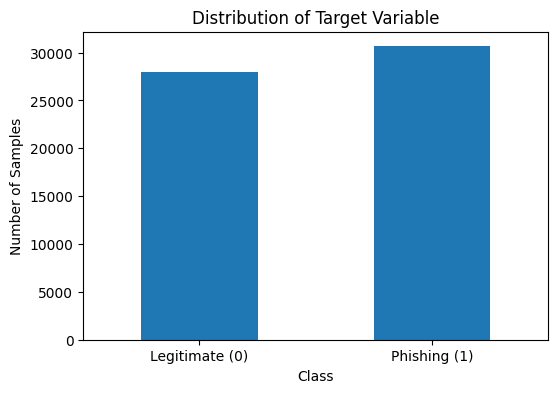

In [10]:
plt.figure(figsize=(6,4))

df["phishing"].value_counts().sort_index().plot(kind="bar")

plt.title("Distribution of Target Variable")
plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.xticks([0,1], ["Legitimate (0)", "Phishing (1)"], rotation=0)

plt.show()

The target variable is relatively balanced, with **52.26% phishing websites** and **47.74% legitimate websites**.

This indicates that there is **no significant class imbalance**, which is beneficial for training machine learning models. Since both classes are well represented, the models are less likely to become biased toward one class, and evaluation metrics such as Accuracy, Precision, Recall, and F1-score will provide a more reliable assessment of model performance.

## 5.1 Feature Distribution

To better understand the dataset, we visualize the distributions of several representative numerical features. These plots help identify the range of values, skewness, and potential outliers.

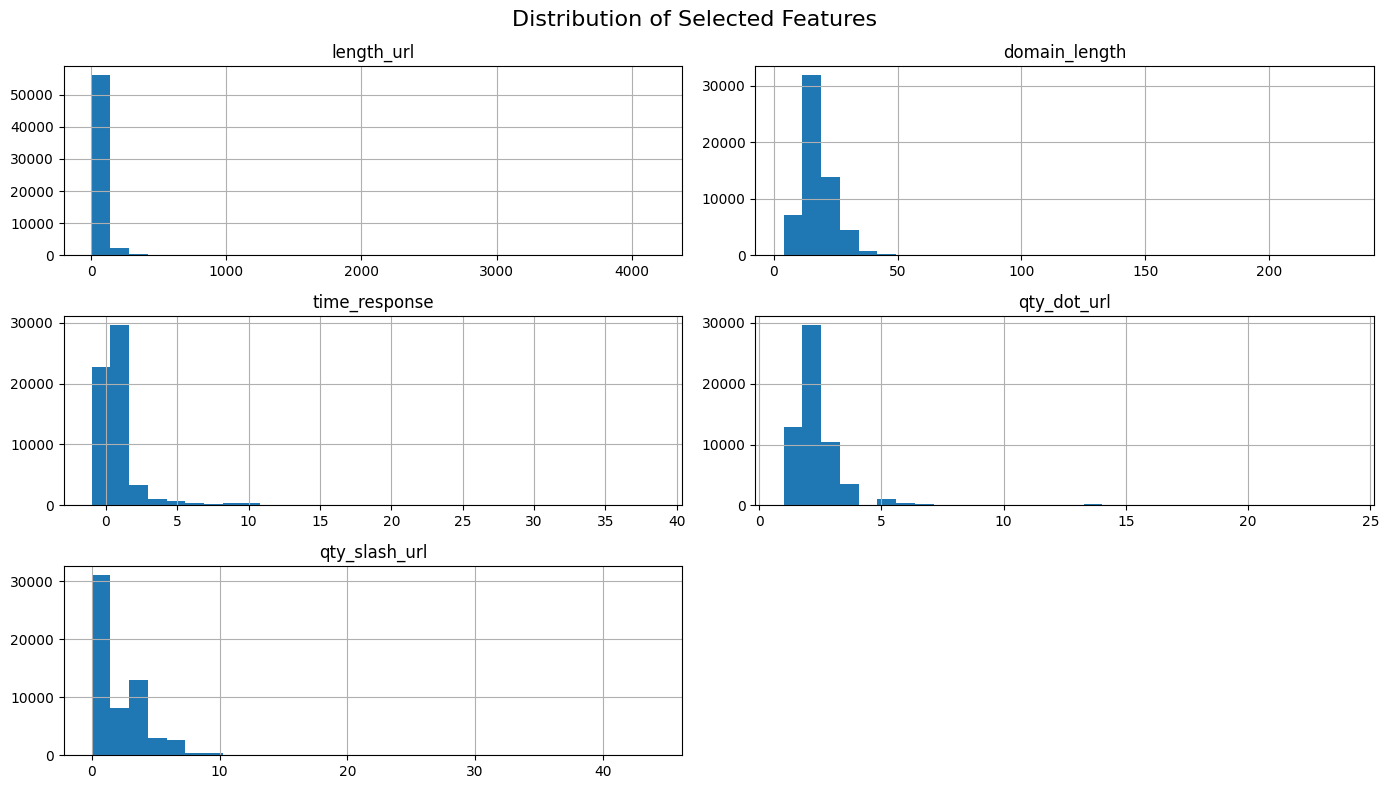

In [11]:
# Select representative features
selected_features = [
    "length_url",
    "domain_length",
    "time_response",
    "qty_dot_url",
    "qty_slash_url"
]

# Plot histograms
df[selected_features].hist(figsize=(14, 8), bins=30)

plt.suptitle("Distribution of Selected Features", fontsize=16)
plt.tight_layout()
plt.show()

The selected features exhibit non-normal distributions and are generally right-skewed. Most URLs have relatively small values for URL length, domain length, and the number of dots or slashes, while a small number of observations contain much larger values.

Several features also contain extreme values (outliers), especially `length_url` and `time_response`. This suggests that phishing websites may occasionally exhibit unusually long URLs or abnormal response times. Because the feature scales differ considerably, feature scaling will be considered before training Logistic Regression, while Random Forest is expected to be less sensitive to these differences.

## 5.2 Outlier Analysis

Outlier analysis is performed to identify unusually large or small observations that may influence the behavior of machine learning models. Boxplots are used to visualize the spread of representative numerical features.

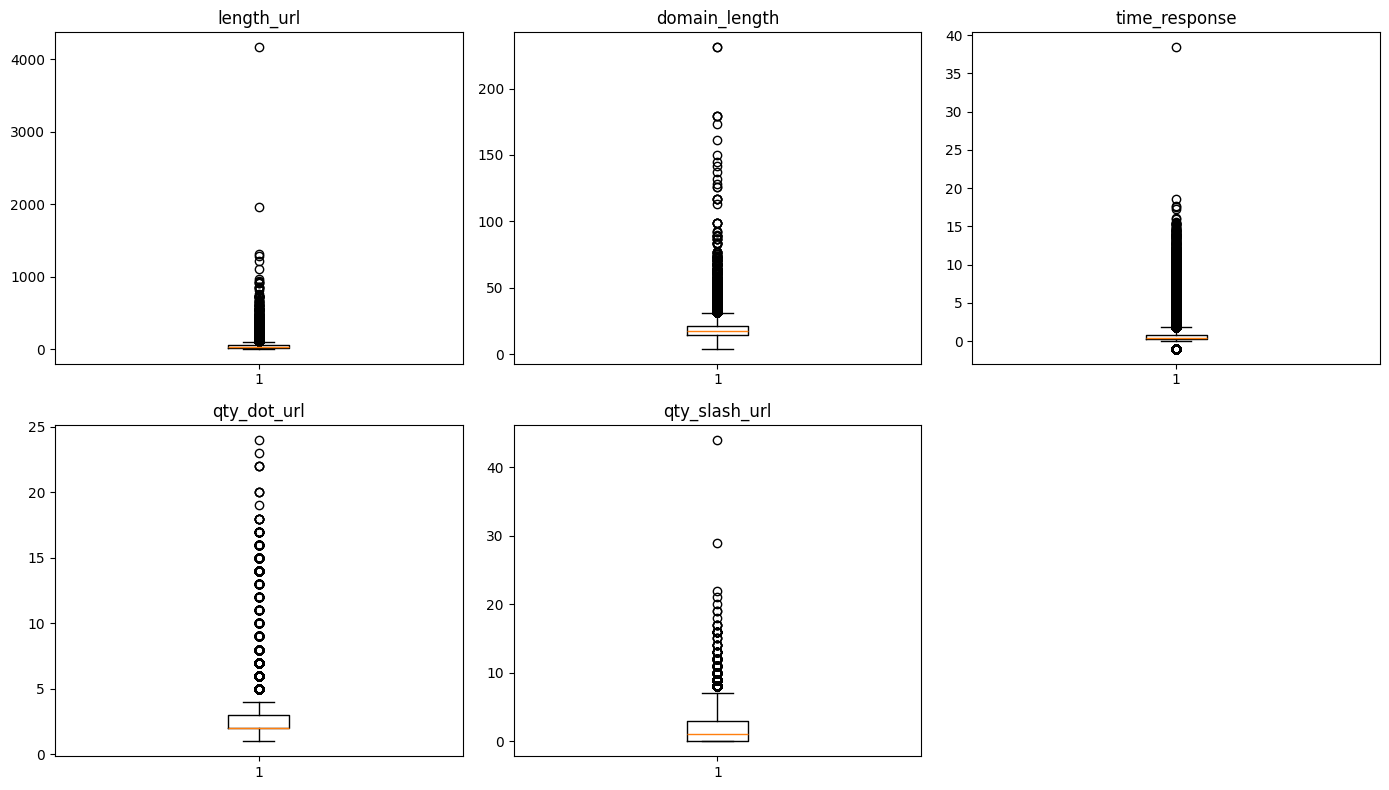

In [15]:
# Representative features for outlier analysis
selected_features = [
    "length_url",
    "domain_length",
    "time_response",
    "qty_dot_url",
    "qty_slash_url"
]

plt.figure(figsize=(14,8))

for i, feature in enumerate(selected_features):
    plt.subplot(2,3,i+1)
    plt.boxplot(df[feature], vert=True)
    plt.title(feature)

plt.tight_layout()
plt.show()

The boxplots reveal that all selected features contain outliers. The largest number of extreme values appears in `length_url`, `domain_length`, and `time_response`, indicating that a small subset of websites has unusually long URLs, longer domain names, or abnormal response times.

These observations are expected in phishing datasets because malicious websites often use complex URL structures to imitate legitimate websites. Some features also contain special values (e.g., `-1`) that represent unavailable information rather than measurement errors.

No outliers are removed in this project. Tree-based models such as Random Forest are generally robust to outliers, and retaining the original observations helps preserve the characteristics of the published dataset.

## 5.3 Temporal Features

The dataset contains several time-related features, including website response time, domain activation time, and domain expiration time.

Although these variables represent temporal information, they are not timestamped observations collected over time. Therefore, this problem is not a time-series prediction task. Instead, these features are treated as numerical predictors describing website characteristics.

In [16]:
temporal_features = [
    "time_response",
    "time_domain_activation",
    "time_domain_expiration"
]

df[temporal_features].describe().T

,count,mean,std,min,25%,50%,75%,max
time_response,58645.0,0.776379,1.572495,-1.0,0.214685,0.426263,0.853995,38.402411
time_domain_activation,58645.0,2531.939483,2799.792419,-1.0,-1.000000,1488.000000,4754.000000,17775.000000
time_domain_expiration,58645.0,293.615074,562.400108,-1.0,-1.000000,125.000000,319.000000,22574.000000


The dataset includes three time-related features: website response time, domain activation time, and domain expiration time. Although these variables describe temporal properties of websites, they are numerical attributes rather than chronological observations, so this is **not** a time-series prediction problem.

The minimum value of **-1** appears in all three features, indicating unavailable or missing external information rather than negative time measurements. In addition, the large ranges and standard deviations suggest considerable variability between websites, which may help distinguish phishing websites from legitimate ones.

## 5.4 GroupBy Analysis

To better understand the differences between legitimate and phishing websites, we compare the average values of selected features across the two classes.

In [17]:
groupby_analysis = df.groupby("phishing")[
    [
        "length_url",
        "domain_length",
        "time_response",
        "qty_dot_url",
        "qty_slash_url"
    ]
].mean()

groupby_analysis

,length_url,domain_length,time_response,qty_dot_url,qty_slash_url
phishing,,,,,
0,23.100971,17.442317,0.683648,2.067719,0.661619
1,64.928280,18.649199,0.861095,2.482233,3.103142


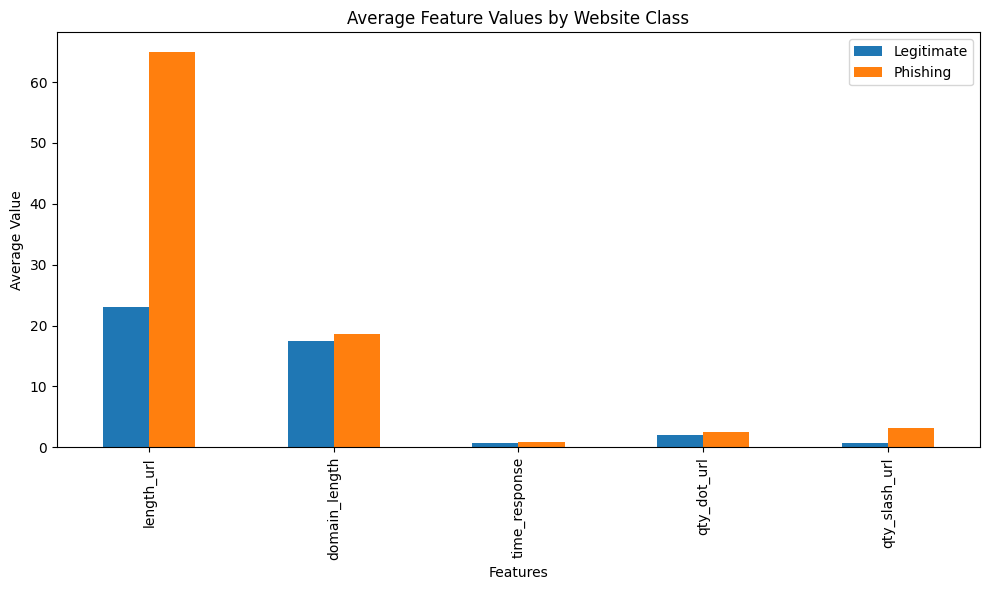

In [18]:
groupby_analysis.T.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Average Feature Values by Website Class")
plt.xlabel("Features")
plt.ylabel("Average Value")
plt.legend(["Legitimate", "Phishing"])

plt.tight_layout()
plt.show()

The GroupBy analysis shows clear differences between legitimate and phishing websites.

The most noticeable difference is **URL length**. On average, phishing websites have much longer URLs (approximately **64.9** characters) than legitimate websites (approximately **23.1** characters). This is consistent with real-world phishing attacks, where attackers often create long and complex URLs to hide malicious content or imitate legitimate websites.

Phishing websites also contain a higher average number of dots and slashes, indicating more complex URL structures. In addition, phishing websites have slightly longer domain names and higher response times.

These differences suggest that URL structure features provide valuable information for distinguishing phishing websites from legitimate ones and are expected to contribute to the predictive performance of the machine learning models.


## 5.5 Correlation Analysis

Correlation analysis is used to identify relationships between numerical features and the target variable.

Because many variables exhibit skewed distributions and contain outliers, **Spearman correlation** is selected instead of Pearson correlation. Spearman correlation measures monotonic relationships using feature ranks rather than raw values, making it more robust to extreme observations and non-normal distributions.

Pearson correlation is more appropriate for linear relationships between normally distributed continuous variables, while Kendall correlation is typically preferred for smaller datasets or rank consistency studies. Given the size and characteristics of this dataset, Spearman provides the most appropriate balance between robustness and interpretability.

In [21]:
# Calculate Spearman correlation
spearman_corr = df.corr(method="spearman", numeric_only=True)["phishing"]

# Remove the target column
spearman_corr = spearman_corr.drop("phishing")

# Select the 15 highest positive correlations
top_corr = spearman_corr.sort_values(ascending=False).head(15)

# Display the values
top_corr

,phishing
qty_slash_url,0.690929
qty_slash_directory,0.687729
directory_length,0.685842
qty_dot_directory,0.642017
qty_dot_file,0.634596
qty_equal_directory,0.627798
qty_and_directory,0.627083
qty_exclamation_directory,0.626988
qty_exclamation_file,0.626948
qty_equal_file,0.626939


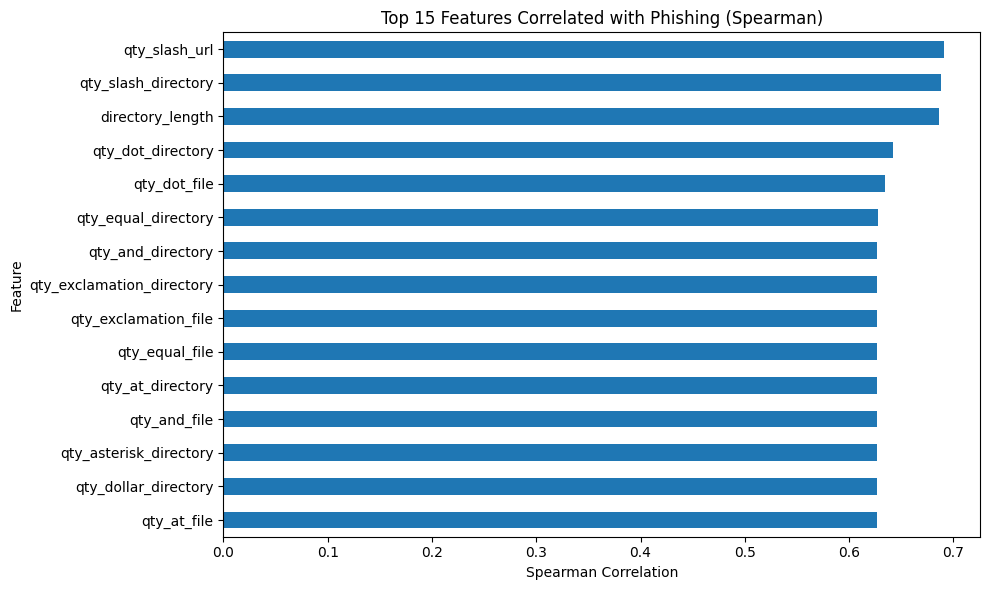

In [22]:
plt.figure(figsize=(10,6))

top_corr.sort_values().plot(kind="barh")

plt.title("Top 15 Features Correlated with Phishing (Spearman)")
plt.xlabel("Spearman Correlation")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

The Spearman correlation analysis identifies the features that have the strongest monotonic relationship with the phishing label.

The highest correlations are observed for features describing the structure of URLs, directories, and files. In particular, the number of slashes in the URL (`qty_slash_url`), the number of slashes within the directory (`qty_slash_directory`), and the directory length (`directory_length`) show the strongest positive associations with phishing websites.

These findings are consistent with real-world phishing attacks, where malicious URLs often contain longer paths, additional directories, and more complex structures designed to imitate legitimate websites or hide malicious content.

Spearman correlation was selected because many features exhibit skewed distributions and contain outliers. Unlike Pearson correlation, Spearman is based on feature ranks and is therefore more robust to non-normal data and extreme values. Although correlation does not imply causation, it provides valuable insight into which features are most informative for phishing detection.

# 6. Feature Engineering and Data Preprocessing

The phishing dataset already contains engineered numerical features extracted from URLs, domains, directories, files, and network-related information. Therefore, no additional feature creation is required.

This section prepares the data for machine learning by:

- Verifying feature types.
- Checking for categorical variables.
- Separating features and target labels.
- Selecting the most informative features.
- Splitting the dataset into training and testing sets.
- Standardizing the data for Logistic Regression.

Dimensionality reduction is not applied because the dataset contains only 111 numerical features and maintaining feature interpretability is important for phishing detection.

In [26]:
# Count the different data types in the dataset

print(df.dtypes.value_counts())

int64      111
float64      1
Name: count, dtype: int64


### Feature Types

The dataset contains only numerical variables. Therefore, no categorical encoding techniques such as One-Hot Encoding or Label Encoding are required.

In [27]:
# Separate input features and target variable

X = df.drop(columns=["phishing"])
y = df["phishing"]

print("Feature matrix:", X.shape)
print("Target vector:", y.shape)

Feature matrix: (58645, 111)
Target vector: (58645,)


In [28]:
# Select the 20 features with the highest Spearman correlation

selected_features = (
    df.corr(method="spearman", numeric_only=True)["phishing"]
      .drop("phishing")
      .abs()
      .sort_values(ascending=False)
      .head(20)
      .index
)

print("Selected Features:")
print(selected_features)

Selected Features:
Index(['qty_slash_url', 'qty_slash_directory', 'directory_length',
       'qty_dot_directory', 'qty_dot_file', 'qty_equal_directory',
       'qty_and_directory', 'qty_exclamation_directory',
       'qty_exclamation_file', 'qty_equal_file', 'qty_at_directory',
       'qty_and_file', 'qty_asterisk_directory', 'qty_dollar_directory',
       'qty_at_file', 'qty_space_directory', 'qty_space_file',
       'qty_asterisk_file', 'qty_hashtag_directory', 'qty_slash_file'],
      dtype='object')


In [29]:
# Keep only the selected features

X_selected = X[selected_features]

print("Reduced feature matrix:", X_selected.shape)

Reduced feature matrix: (58645, 20)


### Feature Selection

Feature selection was performed using Spearman correlation. The 20 features with the strongest relationship to the target variable were selected.

This reduces the dimensionality of the input space while preserving the features that are most relevant for phishing detection.

In [30]:
# Split the selected dataset

X_train, X_test, y_train, y_test = train_test_split(
    X_selected,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])

Training samples: 46916
Testing samples : 11729


In [31]:
# Standardize the selected features

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")

Feature scaling completed.


### Feature Scaling

Feature scaling was applied using StandardScaler.

Scaling is required for Logistic Regression because it is sensitive to differences in feature magnitude.

Random Forest does not require feature scaling because it is based on decision trees rather than distance or gradient optimization.

In [32]:
print("Dimensionality reduction was not applied.")
print("The dataset contains only 111 numerical features,")
print("and maintaining feature interpretability is important.")

Dimensionality reduction was not applied.
The dataset contains only 111 numerical features,
and maintaining feature interpretability is important.


# 7. Model Training

Two machine learning models are trained and evaluated.

- Logistic Regression is selected as a simple baseline classifier.
- Random Forest is selected because it can model complex, non-linear relationships and is widely used for phishing detection.

In [33]:
# Train Logistic Regression

log_model = LogisticRegression(
    random_state=RANDOM_STATE,
    max_iter=1000
)

log_model.fit(X_train_scaled, y_train)

print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


In [34]:
# Predict on the test set

y_pred_log = log_model.predict(X_test_scaled)
y_prob_log = log_model.predict_proba(X_test_scaled)[:, 1]

In [35]:
# Evaluate Logistic Regression

log_accuracy = accuracy_score(y_test, y_pred_log)
log_precision = precision_score(y_test, y_pred_log)
log_recall = recall_score(y_test, y_pred_log)
log_f1 = f1_score(y_test, y_pred_log)
log_auc = roc_auc_score(y_test, y_prob_log)

print(f"Accuracy : {log_accuracy:.4f}")
print(f"Precision: {log_precision:.4f}")
print(f"Recall   : {log_recall:.4f}")
print(f"F1 Score : {log_f1:.4f}")
print(f"ROC-AUC  : {log_auc:.4f}")

Accuracy : 0.8245
Precision: 0.8402
Recall   : 0.8200
F1 Score : 0.8300
ROC-AUC  : 0.8972


In [36]:
# Detailed classification report

print(classification_report(y_test, y_pred_log))

              precision    recall  f1-score   support

           0       0.81      0.83      0.82      5600
           1       0.84      0.82      0.83      6129

    accuracy                           0.82     11729
   macro avg       0.82      0.82      0.82     11729
weighted avg       0.82      0.82      0.82     11729



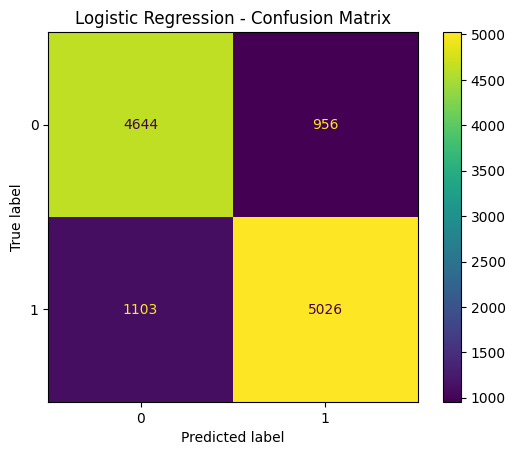

In [37]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred_log)

ConfusionMatrixDisplay(confusion_matrix=cm).plot()

plt.title("Logistic Regression - Confusion Matrix")

plt.show()

The Logistic Regression model serves as a baseline classifier. Although it assumes a linear decision boundary, it provides an effective reference for comparing more advanced models such as Random Forest.

# 8. Random Forest Model

Random Forest is selected as the primary classification model because it combines multiple decision trees, captures non-linear relationships, and is naturally robust to outliers and feature interactions.

In [38]:
# Train Random Forest classifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("Random Forest trained successfully.")

Random Forest trained successfully.


In [39]:
# Predict on the test set

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

In [40]:
# Evaluate Random Forest

rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)
rf_auc = roc_auc_score(y_test, y_prob_rf)

print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1 Score : {rf_f1:.4f}")
print(f"ROC-AUC  : {rf_auc:.4f}")

Accuracy : 0.8436
Precision: 0.8455
Recall   : 0.8572
F1 Score : 0.8513
ROC-AUC  : 0.9161


In [41]:
# Detailed classification report

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.84      0.83      0.83      5600
           1       0.85      0.86      0.85      6129

    accuracy                           0.84     11729
   macro avg       0.84      0.84      0.84     11729
weighted avg       0.84      0.84      0.84     11729



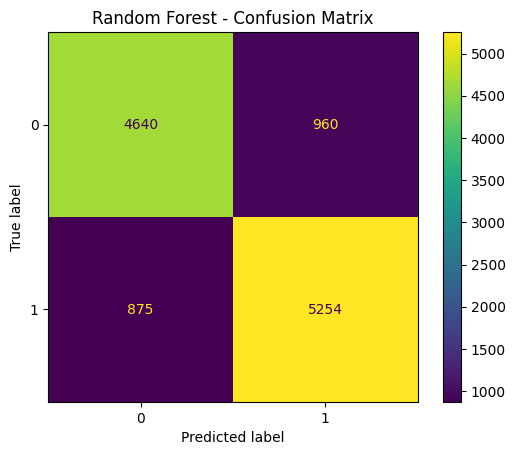

In [42]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred_rf)

ConfusionMatrixDisplay(confusion_matrix=cm).plot()

plt.title("Random Forest - Confusion Matrix")

plt.show()


Random Forest is expected to outperform Logistic Regression because it can model complex interactions between features without assuming a linear relationship. It is also less sensitive to outliers and does not require feature scaling.

# 9. Model Comparison

The performance of Logistic Regression and Random Forest is compared using the evaluation metrics obtained on the test dataset.

In [43]:
# Compare model performance

comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"],
    "Logistic Regression": [
        log_accuracy,
        log_precision,
        log_recall,
        log_f1,
        log_auc
    ],
    "Random Forest": [
        rf_accuracy,
        rf_precision,
        rf_recall,
        rf_f1,
        rf_auc
    ]
})

comparison

,Metric,Logistic Regression,Random Forest
0,Accuracy,0.824452,0.843550
1,Precision,0.840187,0.845510
2,Recall,0.820036,0.857236
3,F1-Score,0.829989,0.851333
4,ROC-AUC,0.897216,0.916134


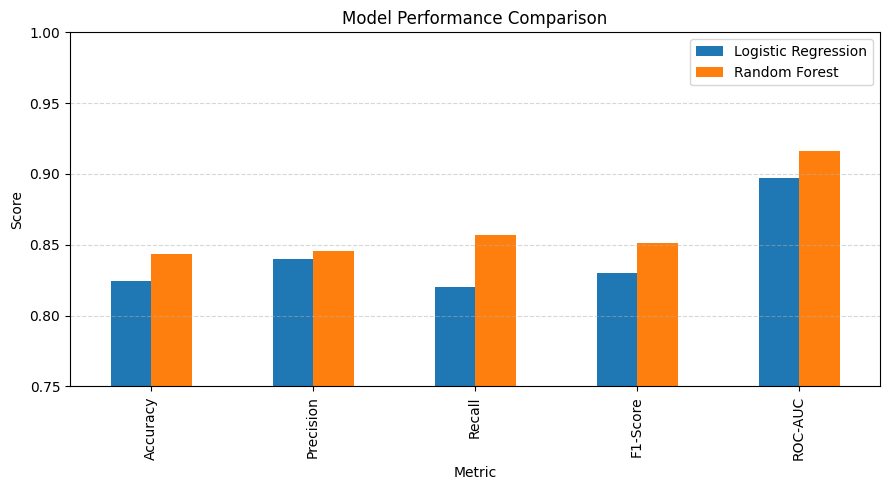

In [44]:
# Plot model comparison

comparison_plot = comparison.set_index("Metric")

comparison_plot.plot(
    kind="bar",
    figsize=(9,5)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0.75,1.0)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

Random Forest achieved higher Accuracy, Recall, F1-score, and ROC-AUC than Logistic Regression. This suggests that the relationships between the features and the phishing label are not purely linear, and that a tree-based ensemble model is better suited to this dataset.

# 10. Feature Importance

Random Forest estimates the importance of each feature based on how much it contributes to reducing impurity across the decision trees.

The most important features provide insight into which URL characteristics are most useful for distinguishing phishing websites from legitimate websites.

In [45]:
# Extract feature importance from the Random Forest model

importance = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
)

importance = importance.sort_values(ascending=False)

importance.head(15)

,0
directory_length,0.295127
qty_slash_url,0.096800
qty_slash_directory,0.081953
qty_dollar_directory,0.060073
qty_dot_file,0.048171
qty_dot_directory,0.046350
qty_equal_directory,0.036013
qty_slash_file,0.035196
qty_and_directory,0.034399
qty_space_file,0.033276


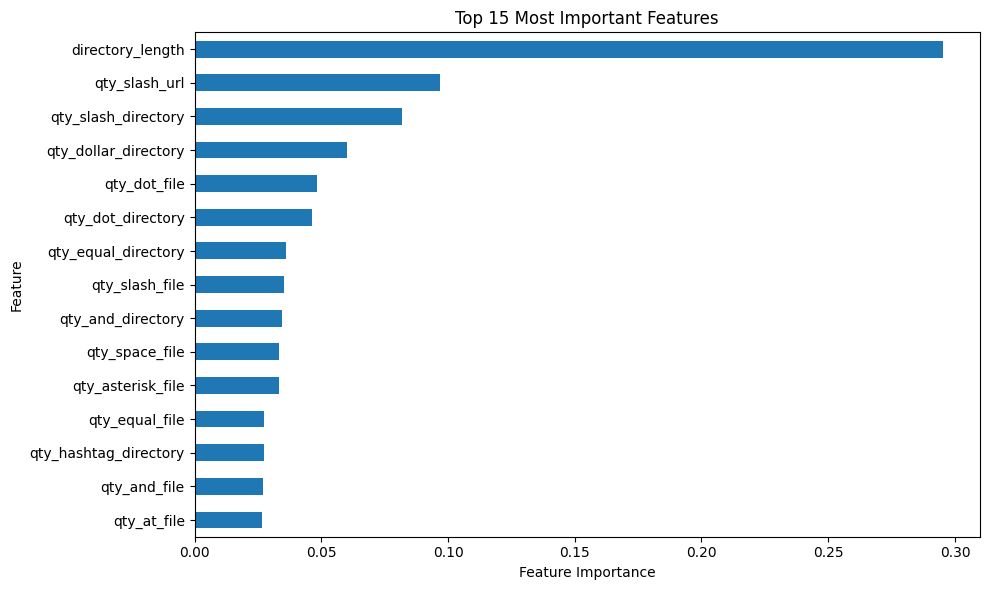

In [46]:
# Plot the 15 most important features

plt.figure(figsize=(10,6))

importance.head(15).sort_values().plot(kind="barh")

plt.title("Top 15 Most Important Features")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

The Random Forest model identifies URL structure features as the most influential for phishing detection. This agrees with the earlier Spearman correlation analysis and suggests that URL complexity plays an important role in distinguishing phishing websites from legitimate ones.

# 11. ROC Curve Comparison

The ROC curve compares the classification performance of both models across different decision thresholds.

A larger Area Under the Curve (AUC) indicates better discrimination between phishing and legitimate websites.

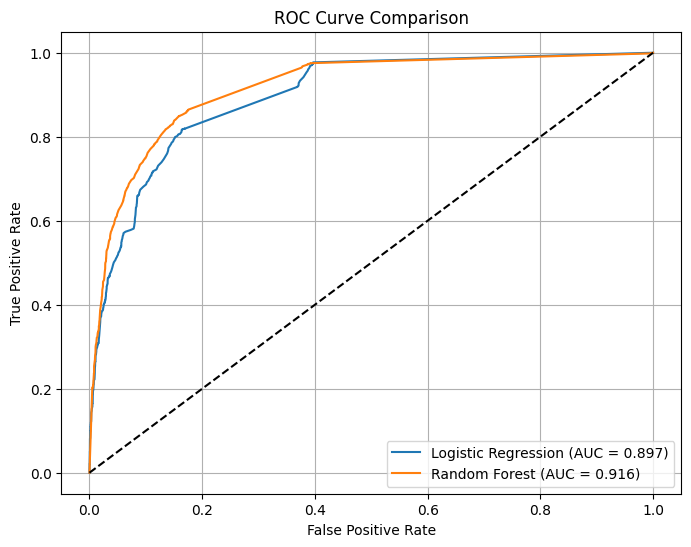

In [47]:
from sklearn.metrics import roc_curve

# Compute ROC curves
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(8,6))

plt.plot(
    fpr_log,
    tpr_log,
    label=f"Logistic Regression (AUC = {log_auc:.3f})"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {rf_auc:.3f})"
)

# Reference line (random classifier)
plt.plot([0,1],[0,1],"k--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend()

plt.grid(True)

plt.show()

# 12. Error Analysis
This section investigates the prediction errors made by the Random Forest model.
The analysis focuses on misclassified samples and compares the number of False Positives and False Negatives to better understand the model's weaknesses.

In [ ]:
# Find incorrectly classified samples

errors = X_test.copy()
errors["True Label"] = y_test.values
errors["Predicted Label"] = y_pred_rf

misclassified = errors[errors["True Label"] != errors["Predicted Label"]]

print("Number of misclassified samples:", len(misclassified))

misclassified.head(10)

Number of misclassified samples: 1835


,qty_slash_url,qty_slash_directory,directory_length,qty_dot_directory,qty_dot_file,qty_equal_directory,qty_and_directory,qty_exclamation_directory,qty_exclamation_file,qty_equal_file,...,qty_asterisk_directory,qty_dollar_directory,qty_at_file,qty_space_directory,qty_space_file,qty_asterisk_file,qty_hashtag_directory,qty_slash_file,True Label,Predicted Label
8833,2,2,22,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
54281,1,1,14,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
36362,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
45189,2,2,6,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
14319,1,1,8,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
28672,3,3,21,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
29098,2,2,24,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
42703,2,2,5,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
9375,0,-1,-1,-1,-1,-1,-1,-1,-1,-1,...,-1,-1,-1,-1,-1,-1,-1,-1,1,0
9856,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0


In [ ]:
# Count False Positives and False Negatives

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_rf)

TN, FP, FN, TP = cm.ravel()

print(f"True Negatives : {TN}")
print(f"False Positives: {FP}")
print(f"False Negatives: {FN}")
print(f"True Positives : {TP}")

True Negatives : 4640
False Positives: 960
False Negatives: 875
True Positives : 5254


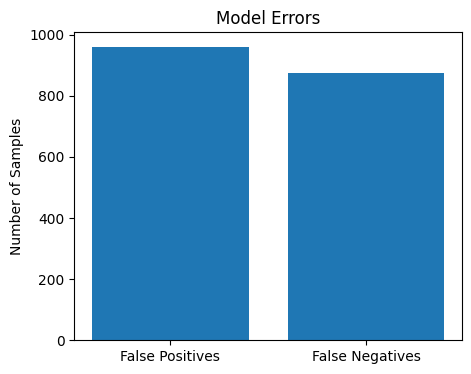

In [53]:
# Visualize False Positives and False Negatives

import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))

plt.bar(
    ["False Positives", "False Negatives"],
    [FP, FN]
)

plt.title("Model Errors")
plt.ylabel("Number of Samples")

plt.show()

The model produces both False Positives and False Negatives. From a cybersecurity perspective, False Negatives are generally more critical because they represent phishing websites that are incorrectly classified as legitimate, potentially exposing users to attacks.